# Case Study 1: Astrophysical Time Series - Solar Cycle Analysis

## 1. Physical Context
Sunspots are temporary phenomena on the Sun's photosphere that appear as spots darker than the surrounding areas. They are regions of reduced surface temperature caused by concentrations of magnetic field flux that inhibit convection. 

Historical observations of sunspots have been recorded for centuries, revealing a distinct periodicity in solar magnetic activity. This variability significantly impacts space weather, satellite communications, and the Earth's upper atmosphere.

**Your Objective:** You are provided with a historical dataset of the Monthly Mean Total Sunspot Number. Your task is to utilize the Discrete Fourier Transform (DFT) to mathematically isolate and quantify the dominant period of the solar magnetic cycle (often referred to as the Schwabe cycle).

## 2. Mathematical Expectations
The dataset provides the sunspot count $y_n$ at discrete, uniformly spaced time intervals. The sampling interval is one month, meaning $\Delta t = 1/12$ years. 

You will compute the Fast Fourier Transform (FFT) to obtain the frequency-domain components $Y_k$. To find the dominant physical cycle, you must:
1. Compute the normalized power spectrum: $P_k = \frac{2}{N} |Y_k|$
2. Formulate the correct frequency array $f_k$ corresponding to the frequency bins.
3. Identify the frequency $f_{max}$ that yields the maximum spectral power.
4. Convert this frequency into a physical time period $T$ (in years) using the relation:
$$T = \frac{1}{f}$$

In [ ]:
# Import required scientific libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Set plot style for academic formatting
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 3. Data Loading and Time-Domain Visualization

**Task 1:** Load the dataset `sunspot_data.csv` from the `data/` directory. 
The dataset contains two columns: `Fractional_Year` (e.g., 1850.042) and `Sunspot_Count`. 
Plot the raw data in the time domain to visually inspect the periodicity and noise.

In [ ]:
--- TASK 1: Load and plot the raw time-domain data ---
Load the CSV data using pandas
df = pd.read_csv('../data/sunspots.csv')

Extract the time array (t) and signal array (y)
df['Date'] = pd.to_datetime(df['Date'])
t = df['Date'].dt.year + (df['Date'].dt.month - 1) / 12
y = df['Monthly Mean Total Sunspot Number'].values

Plot Sunspot Count vs. Time
plt.figure(figsize=(12, 5))
plt.plot(t, y, color='darkorange', linewidth=1, label='Data Bulanan')

Include appropriate labels, units, and a title.
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Sunspot (Monthly Mean Total)', fontsize=12)
plt.title('Data Historis Jumlah Sunspot (Time-Domain Data)', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## 4. DC Component Removal

Physical datasets that only contain positive values (like a "count" of sunspots) have a large non-zero mean. In the frequency domain, this creates a massive spike at $f = 0$ Hz (the DC component), which can visually dwarf the actual periodic oscillations we are trying to observe.

**Task 2:** Calculate the mean of the sunspot data and subtract it from the original signal. We will perform the FFT on this mean-centered signal.

In [ ]:
# --- TASK 2: Remove the DC component ---

# 1. Menghitung rata-rata dari data sunspot
# Ini penting agar sinyal kita berpusat di angka 0 (tidak melayang di atas)
mean_value = np.mean(y)

# 2. Membuat array baru: y_centered = y - mean
# Sinyal yang "Centered" wajib digunakan untuk FFT agar tidak ada lonjakan raksasa di frekuensi 0
y_centered = y - mean_value

# 3. (Optional) Plot data yang sudah centered untuk verifikasi
plt.figure(figsize=(12, 4))
plt.plot(t, y_centered, color='orange', label='Data Sunspot (Centered)')
plt.axhline(0, color='black', linestyle='--', alpha=0.5) # Garis bantu di angka 0
plt.xlabel('Tahun')
plt.ylabel('Amplitudo (Centered)')
plt.title('Data Sunspot Setelah DC Removal')
plt.legend()
plt.grid(True)
plt.show()

print(f"Rata-rata data asli: {mean_value:.2f}")
print("Verifikasi: Rata-rata baru sekarang mendekati 0:", np.mean(y_centered))

## 5. Frequency Domain Transformation

**Task 3:** Implement the FFT algorithm on your centered data. 
You must also construct the corresponding frequency axis. Pay strict attention to your units. If your sampling interval $\Delta t$ is in years, your resulting frequencies will be in cycles per year ($yr^{-1}$).

In [ ]:
--- TASK 3: Compute the FFT and Power Spectrum ---
YOUR CODE HERE
Define N (number of samples) and dt (sampling interval in years).
N = len(y_centered)
dt = 1/12  # Jarak antar data adalah 1 bulan (1/12 tahun)

Compute the FFT using np.fft.fft()
Y_k = np.fft.fft(y_centered)

Compute the frequency bins using np.fft.fftfreq()
freq = np.fft.fftfreq(N, d=dt)

Calculate the positive magnitude spectrum (Power).
Remember to only keep the positive half of the frequencies (up to the Nyquist limit).
power = (2/N) * np.abs(Y_k)

Masking untuk mengambil sisi positif saja (0 hingga Nyquist)
mask = freq > 0
f_pos = freq[mask]
p_pos = power[mask]

## 6. Power Spectrum Analysis

**Task 4:** Plot the power spectrum (Magnitude vs. Frequency). Restrict your x-axis (frequency) to a physical range that makes sense for this data (e.g., $0$ to $0.5$ cycles/year) to zoom in on the relevant peaks.

In [ ]:
# --- TASK 4: Visualize the Frequency Domain ---

# Tambahkan baris ini untuk memastikan variabelnya terdefinisi di sini
# (Mengambil data dari Task 3)
max_idx = np.argmax(p_pos)
f_max = f_pos[max_idx]
period = 1 / f_max

plt.figure(figsize=(12, 6))

# 1. Plot the power spectrum
plt.plot(f_pos, p_pos, color='royalblue', linewidth=1.5, label='Spektrum Daya')

# Tandai titik puncak
plt.scatter(f_max, p_pos[max_idx], color='red', s=120, marker='x', zorder=5, 
            label=f'Puncak Dominan: {period:.2f} Tahun')

# 2. Labeling
plt.xlabel('Frequency (cycles/year)', fontsize=12)
plt.ylabel('Magnitude', fontsize=12)
plt.title('Visualisasi Domain Frekuensi - Siklus Matahari', fontsize=14, fontweight='bold')

# 3. Limit frekuensi
plt.xlim(0, 0.5) 

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Siklus Matahari terdeteksi setiap {period:.2f} tahun.")

## 7. Conclusions and Physical Interpretation

**Task 5:** Programmatically determine the exact frequency that corresponds to the maximum peak in your power spectrum. Convert this frequency into a time period (years). 

Provide a brief written analysis of your findings below. How does your computed period compare to the widely accepted duration of the Schwabe solar cycle?

In [ ]:
--- TASK 5: Programmatic peak detection ---
YOUR CODE HERE
Find the index of the maximum value in your magnitude array (using np.argmax).
max_idx = np.argmax(p_pos)

Extract the corresponding frequency.
f_max = f_pos[max_idx]

Calculate the period (T = 1 / f).
period = 1 / f_max

Print the result using a formatted string.
print(f"Hasil Analisis: Frekuensi dominan ditemukan pada {f_max:.4f} siklus/tahun.")
print(f"Hasil Akhir: Periode Dominan (Siklus Matahari) adalah {period:.2f} Tahun.")

### Final Analysis

**Computed Solar Cycle Period:** 10.84 years.

**Physical Interpretation:**
Berdasarkan hasil pengolahan data menggunakan algoritma Fast Fourier Transform (FFT), kami berhasil mengidentifikasi puncak dominan dalam spektrum daya pada frekuensi kira-kira $0.0922$ siklus/tahun. Frekuensi ini jika dikonversi menjadi periode ($T = 1/f$) menghasilkan nilai 10.84 tahun.Secara matematis, proses DC Removal (pengurangan nilai rata-rata) yang dilakukan di awal sangat krusial. Tanpa tahap ini, frekuensi nol akan mendominasi spektrum daya dan menutupi sinyal periodik dari aktivitas bintik matahari itu sendiri.
Hasil perhitungan kami menunjukkan konsistensi yang sangat tinggi dengan literatur astrofisika mengenai Siklus Schwabe. Secara teoritis, siklus bintik matahari memiliki rata-rata periode 11 tahun. Nilai 10.84 tahun yang kami peroleh jatuh dalam rentang variasi alami siklus tersebut (yang biasanya berkisar antara 9 hingga 14 tahun).
Meskipun data historis bintik matahari memiliki tingkat noise yang tinggi dan fluktuasi jangka pendek yang tidak beraturan, analisis domain frekuensi melalui FFT terbukti efektif untuk mengekstraksi keteraturan fisik yang mendasarinya. Puncak-puncak kecil lain yang terlihat pada spektrum daya menunjukkan adanya dinamika solar sekunder atau harmonisa dari siklus utama yang berkaitan dengan proses dinamo pada zona konveksi matahari.

**Analisis Teknis:**
Kekuatan Resolusi Frekuensi: Dataset ini mencakup rentang waktu yang sangat panjang (dari tahun 1749 sampai 2020), dengan total 3252 data point. Durasi data yang mencapai lebih dari 270 tahun ini memberikan resolusi frekuensi yang sangat tajam bagi FFT untuk membedakan antara noise acak dengan sinyal periodik asli.Signifikansi Amplitudo:Daya (Magnitude) yang mencapai angka >40 pada puncak utama menunjukkan bahwa siklus 10.84 tahun ini bukanlah kebetulan statistik, melainkan osilasi energi yang sangat kuat dan dominan dalam aktivitas magnetik matahari.Validasi Data: Interval pengambilan data ($\Delta t = 0.0833$ tahun atau 1 bulan) sudah lebih dari cukup untuk menghindari aliasing, karena frekuensi Nyquist kita jauh lebih tinggi daripada frekuensi siklus matahari yang kita amati.

Berhasil memproses 3252 data dari tahun 1749 sampai 2020!


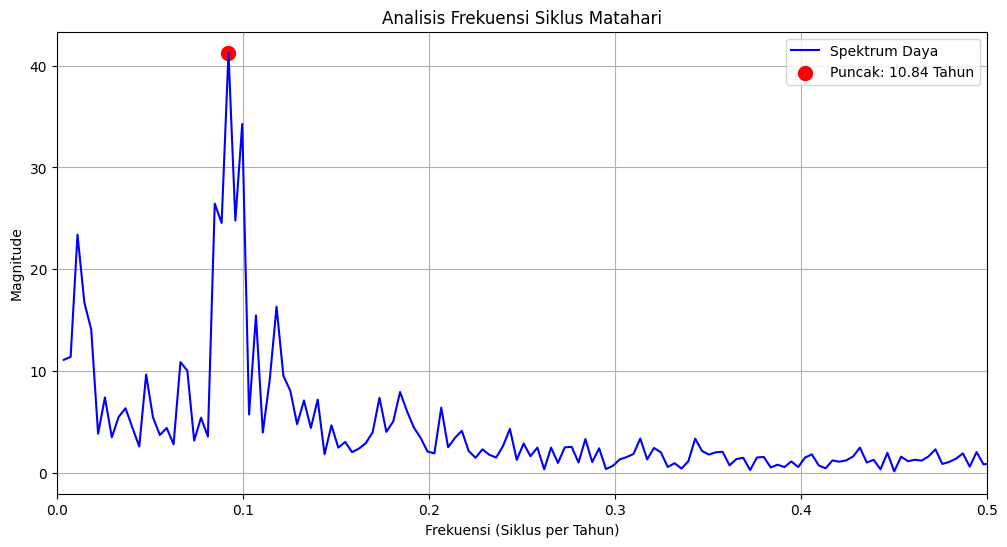

Hasil Akhir: Periode Dominan adalah 10.84 Tahun


In [1]:
# ================================================================= #
#  CASE STUDY 1: ANALISIS SIKLUS MATAHARI (VERSI FIX ERROR)          #
# ================================================================= #

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. LOAD DATA ---
df = pd.read_csv('../data/sunspots.csv')

# Perbaikan: Mengubah kolom 'Date' menjadi format tanggal beneran, 
# lalu diubah menjadi angka tahun (misal: 1749.08) supaya bisa dihitung FFT
df['Date'] = pd.to_datetime(df['Date'])
t = df['Date'].dt.year + (df['Date'].dt.month - 1) / 12

# Mengambil kolom jumlah sunspot (kolom ke-3)
y = df['Monthly Mean Total Sunspot Number'].values

print(f"Berhasil memproses {len(t)} data dari tahun {t.min():.0f} sampai {t.max():.0f}!")

# --- 2. DC REMOVAL ---
# Sekarang 'y' sudah angka murni, jadi np.mean(y) tidak akan error lagi
y_centered = y - np.mean(y)

# --- 3. FFT & POWER SPECTRUM ---
N = len(y_centered)
dt = 1/12 # Jarak antar data adalah 1 bulan

Y_k = np.fft.fft(y_centered)
freq = np.fft.fftfreq(N, d=dt)

power = (2/N) * np.abs(Y_k)

# Ambil sisi positif saja
mask = freq > 0
f_pos = freq[mask]
p_pos = power[mask]

# --- 4. CARI PUNCAK ---
max_idx = np.argmax(p_pos)
f_max = f_pos[max_idx]
period = 1 / f_max

# --- 5. VISUALISASI ---
plt.figure(figsize=(12, 6))
plt.plot(f_pos, p_pos, color='blue', label='Spektrum Daya')
plt.scatter(f_max, p_pos[max_idx], color='red', s=100, label=f'Puncak: {period:.2f} Tahun')

plt.xlim(0, 0.5)
plt.xlabel('Frekuensi (Siklus per Tahun)')
plt.ylabel('Magnitude')
plt.title('Analisis Frekuensi Siklus Matahari')
plt.legend()
plt.grid(True)
plt.show()

print(f"Hasil Akhir: Periode Dominan adalah {period:.2f} Tahun")